## Exploration des données (statistiques, sélection des features)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
# chargement données
dftele = pd.read_csv("machines_telemetry.csv")
dfmeta = pd.read_csv("machines_metadata.csv")
dfhisto = pd.read_csv("maintenance_history.csv")

In [6]:
print(f"nombre de machines dans le fichier telemetry : {len(dftele.machine_id.unique())}")
print(f"nombre de machines dans le fichier metadata : {len(dfmeta.machine_id.unique())}")
print(f"nombre de machines dans le fichier history : {len(dfhisto.machine_id.unique())}")

nombre de machines dans le fichier telemetry : 40
nombre de machines dans le fichier metadata : 120
nombre de machines dans le fichier history : 111


👉 Premiere observation : nous disposons des mesures capteur de seulement 40 machines, sur 120 recensées dans les métadonnées et dans l'historique des pannes.
Nous sommes donc contraint de faire sans ces données pour entrainer un modèle, et que le problème de la collecte de données est clairement à résoudre.

In [52]:
# filtrage des lignes des datasets
machines_data_list = list(dftele.machine_id.unique())
dfhisto = dfhisto[dfhisto['machine_id'].isin(machines_data_list)]
dfmeta = dfmeta[dfmeta['machine_id'].isin(machines_data_list)]

In [14]:
# --> check NaN
print(f"Nombre de valeurs manquantes :\n {dftele.isna().sum()}")

Nombre de valeurs manquantes :
 timestamp               0
machine_id              0
machine_type            0
temperature_celsius     0
vibration_mm_s          0
power_consumption_kw    0
pressure_bar            0
cycles_count            0
status                  0
error_code              0
is_producing            0
will_fail_48h           0
dtype: int64


In [15]:
# --> check si doublons
doublons = dftele.groupby(['timestamp','machine_id']).agg({'machine_id':'count'})
doublons = doublons[doublons['machine_id']>1]
print(f"Nombre de doublons :{len(doublons)}")


Nombre de doublons :0


In [16]:
# --> check valeurs abberantes
dftele.describe()

,temperature_celsius,vibration_mm_s,power_consumption_kw,pressure_bar,cycles_count
count,700840.000000,700840.000000,700840.000000,700840.000000,700840.000000
mean,61.099089,0.242285,310.829860,5.998462,99.697379
std,9.893634,0.115924,99.632942,0.120969,29.333239
min,37.070000,0.000000,42.390000,5.000000,20.000000
25%,53.420000,0.154000,250.750000,5.900000,74.000000
50%,58.990000,0.237000,295.560000,6.000000,100.000000
75%,71.100000,0.327000,422.520000,6.100000,125.000000
max,102.280000,1.078000,538.520000,6.500000,150.000000


👉 Deuxieme observation : pas de doublons ni de valeurs manquantes, pas de valeurs abberantes repérées (les min/max/moyenne/médiane semblent cohérentes)

👉 Troisième observation : 1 valeur par capteur par heure (donc 24 valeurs par jour, par capteur)

In [53]:
# ratio classes
dftele['will_fail_48h'].value_counts()

will_fail_48h
False    692680
True       8160
Name: count, dtype: int64

👉 Quatrième observation : classes très désiquilibrées (8160/700840 = 0.0116), classe à prédire = 1,16%, 
et si on considère que plusieurs observations positives correspondent à une panne réelle, c'est extrême.

### Recherche de corrélations

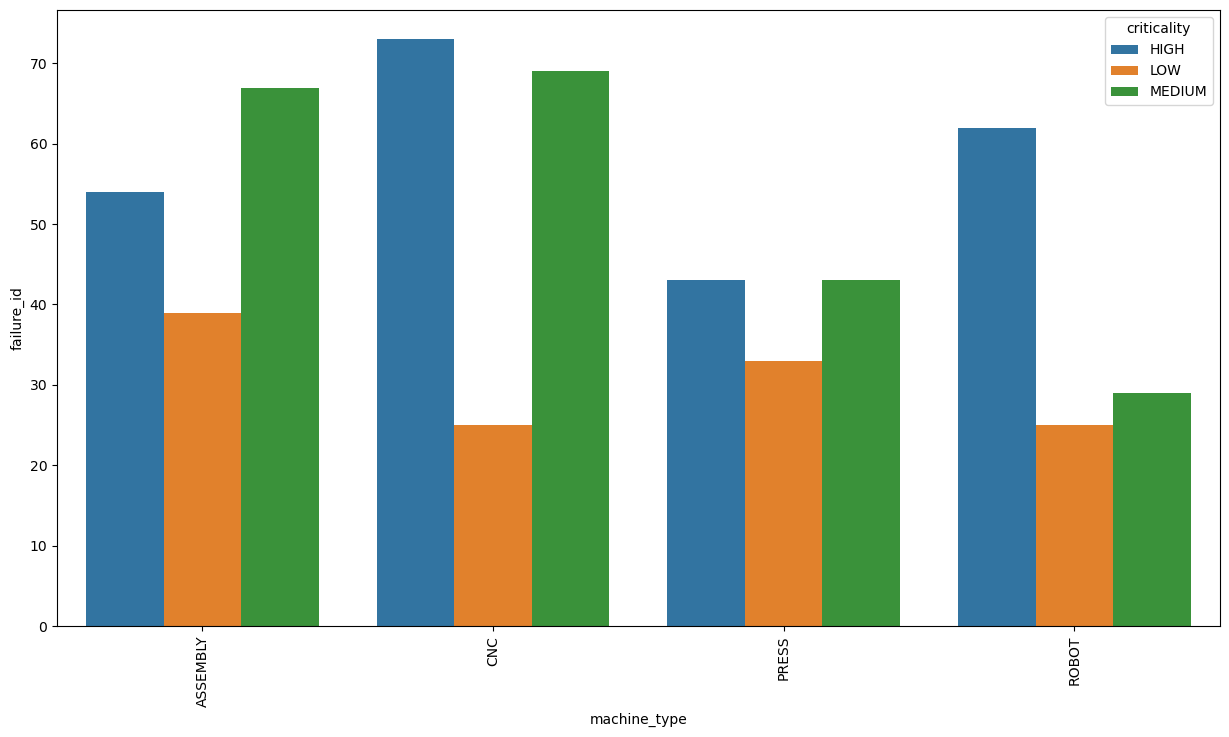

In [19]:
# nb de pannes par type de machine (et leur criticité pour l'entreprise)
dfmeta = pd.read_csv("machines_metadata.csv")
dfhisto = pd.read_csv("maintenance_history.csv")
dfstatscrit = pd.merge(dfhisto,dfmeta,how='left',on='machine_id')
dfstatscrit = dfstatscrit.groupby(['machine_type','criticality']).agg({'failure_id':'count'}).reset_index()
# les machines CNC sont les plus impactées en pannes, et leur criticité est la plus importante
# vient ensuite les ASSEMBLY (machines d'assemblage ?)
plt.figure(figsize=(15,8))
sns.barplot(x="machine_type", y="failure_id",hue='criticality',data=dfstatscrit)
plt.xticks(rotation=90)
plt.show()

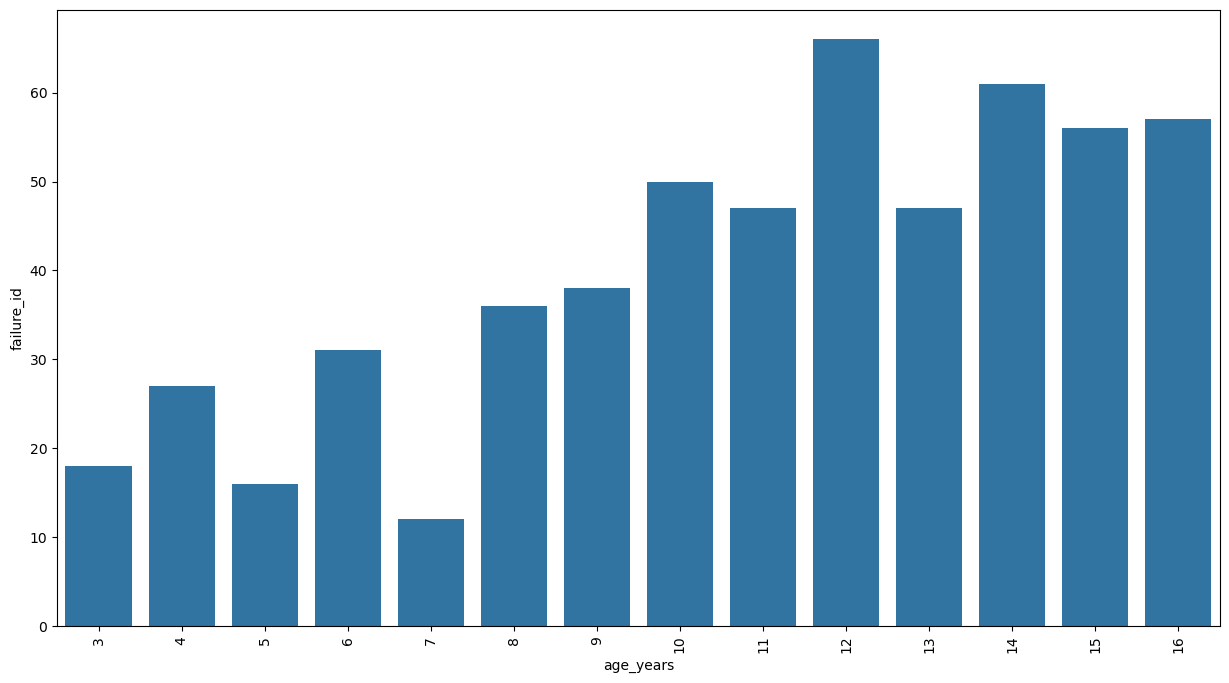

In [20]:
# nb de pannes par type de machine (et leur criticité pour l'entreprise)
dfmeta = pd.read_csv("machines_metadata.csv")
dfhisto = pd.read_csv("maintenance_history.csv")
dfstatsage = pd.merge(dfhisto,dfmeta,how='left',on='machine_id')
dfstatsage = dfstatsage.groupby(['age_years']).agg({'failure_id':'count'}).reset_index()
# sans surprises, plus la machine est ancienne, plus la probabilité d'une panne augmente
plt.figure(figsize=(15,8))
sns.barplot(x="age_years", y="failure_id",data=dfstatsage)
plt.xticks(rotation=90)
plt.show()

👉 Plus l'âge des machines avance, plus elles sont susceptibles de tomber en panne
👉 Les machines les plus souvent en panne sont les machines de type CNC, alors que ces machines sont manifestements critiques ou importantes pour la production

In [21]:
# évolution panne machine M-001 ayant ayant eu lieu le 10 Mars 2024
dftele_fail = dftele[dftele['will_fail_48h']==1]
dftele_fail_M1 = dftele_fail[(dftele['machine_id']=="M-001")&(dftele['will_fail_48h']==1)&(dftele['timestamp']>="2024-03-06")&(dftele['timestamp']<="2024-03-10")]
dfhisto_M1 = dfhisto[(dfhisto['failure_id']=="F-00001")]

C:\Users\Raging\AppData\Local\Temp\ipykernel_9272\3071671624.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dftele_fail_M1 = dftele_fail[(dftele['machine_id']=="M-001")&(dftele['will_fail_48h']==1)&(dftele['timestamp']>="2024-03-06")&(dftele['timestamp']<="2024-03-10")]


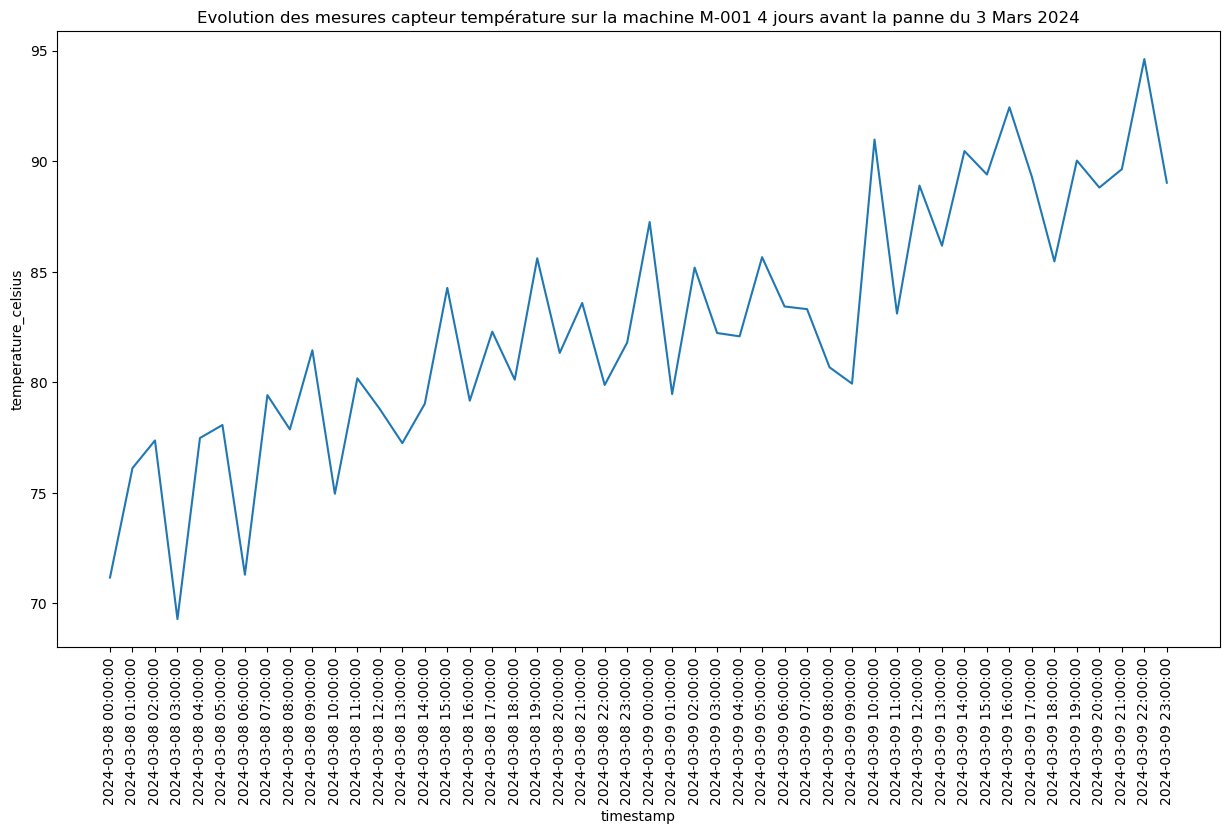

In [23]:
# Température augmente avant la panne
plt.figure(figsize=(15,8))
sns.lineplot(x="timestamp", y="temperature_celsius",data=dftele_fail_M1)
plt.title("Evolution des mesures capteur température sur la machine M-001 les 4 jours précédant la panne du 3 Mars 2024")
plt.xticks(rotation=90)
plt.show()

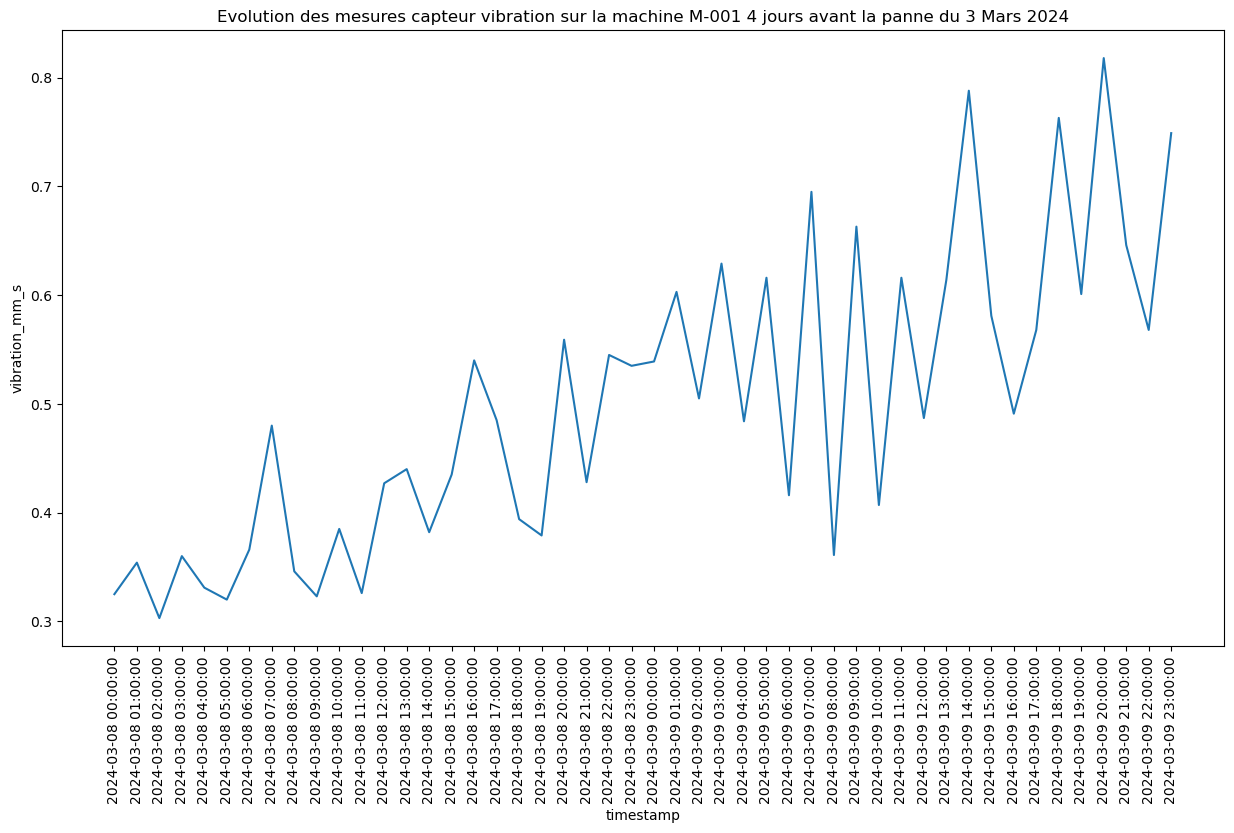

In [24]:
# Les Vibrations augmentent avant la panne
plt.figure(figsize=(15,8))
sns.lineplot(x="timestamp", y="vibration_mm_s",data=dftele_fail_M1)
plt.title("Evolution des mesures capteur vibration sur la machine M-001 les 4 jours précédant la panne du 3 Mars 2024")
plt.xticks(rotation=90)
plt.show()

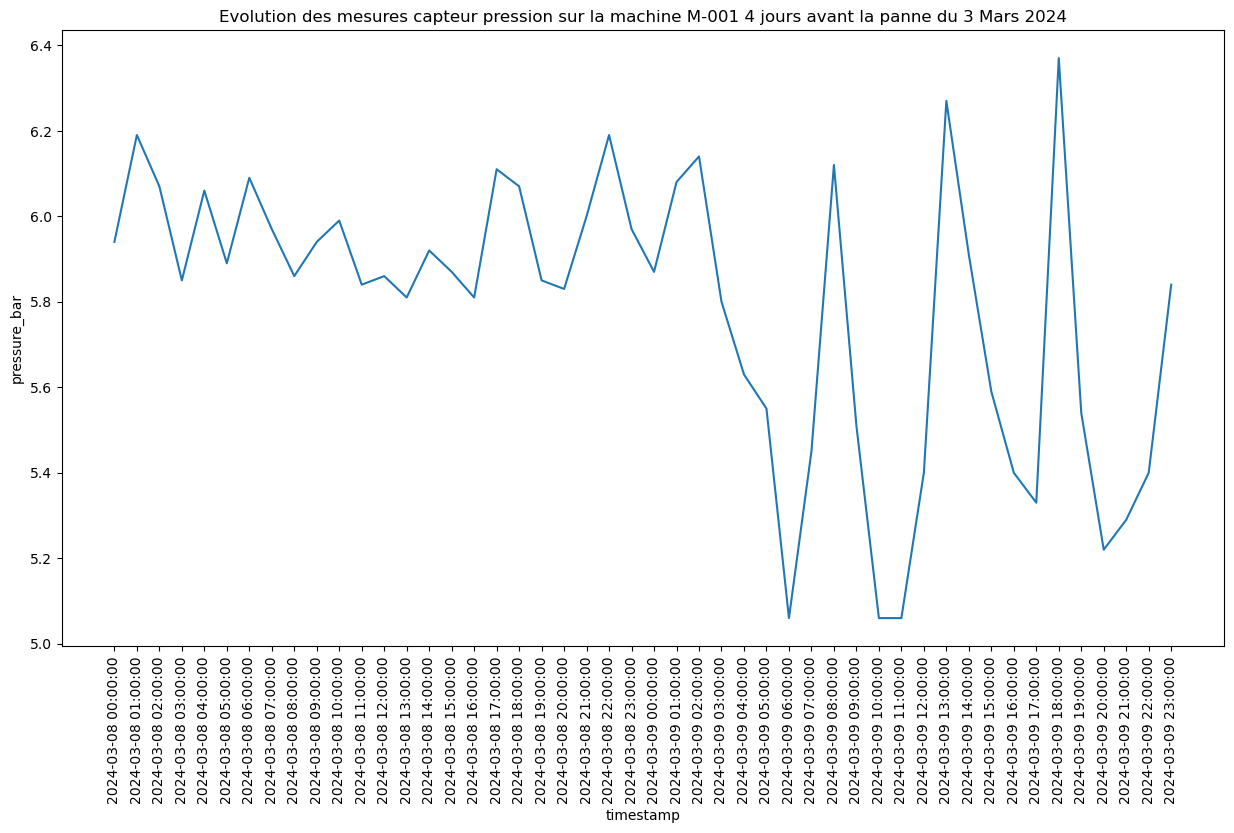

In [25]:
# Fortes fluctuations de la pression avant la panne
plt.figure(figsize=(15,8))
sns.lineplot(x="timestamp", y="pressure_bar",data=dftele_fail_M1)
plt.title("Evolution des mesures capteur pression sur la machine M-001 les 4 jours précédant la panne du 3 Mars 2024")
plt.xticks(rotation=90)
plt.show()

### Transformation / Enrichissement des données (recalcul de l'age, moyennes glissantes)

In [42]:
def data_load(df_tele,df_meta):
    # jointure dataframes telemetry et metadata
    df = pd.merge(df_tele,df_meta,how='left',on='machine_id')
    # on garde les champs qui semblent interressants
    features = ['timestamp',
                'machine_id',
                'machine_type_x',
                'temperature_celsius',
                'vibration_mm_s',
                'power_consumption_kw',
                'pressure_bar',
                'install_date',
                'last_major_overhaul',
                'error_code',
                'will_fail_48h']
    df = df[features]
    return df

def data_transform(df):
    # convertion type en datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'],format='%Y-%m-%d %H:%M:%S')
    df['install_date'] = pd.to_datetime(df['install_date'],format='%Y-%m-%d')
    df['last_major_overhaul'] = pd.to_datetime(df['last_major_overhaul'],format='%Y-%m')

    # ajout d'un champs age calculé dynamiquement (plus précis)
    df['age'] = ((df['timestamp']-df['install_date']).dt.days)/7
    df['age'] = abs(df['age'].astype('int64'))

    # ajout d'un champs age depuis la dernière panne
    df['last_overhaul_age'] = ((df['timestamp']-df['last_major_overhaul']).dt.days)/7
    df['last_overhaul_age'] = df['last_overhaul_age'].astype('int64')
    df['last_overhaul_age'] = abs(df['last_overhaul_age'].astype('int64'))

    # passage du boolen à un entier pour la classe
    df['will_fail_48h'] = df['will_fail_48h'].replace({'False':0,'True':1})
    df['will_fail_48h'] = df['will_fail_48h'].astype('int')
    
    # sélection
    features = ['timestamp',
                'machine_id',
                'temperature_celsius',
                'vibration_mm_s',
                'power_consumption_kw',
                'pressure_bar',
                'machine_type_x',
                'last_overhaul_age',
                'age',         
                'will_fail_48h']
    df = df[features]
    return df

# enrichissement avec moyennes glissantes (uniquement sur température et vibration)
def data_enrich(df):
    WINDOWS = {"24h": 24,
              "48h":48}

    SENSORS = [
    "temperature_celsius",
    "vibration_mm_s",
    ]

    for sensor in SENSORS:
        for label, window in WINDOWS.items():
            col_name = f"{sensor}_mean_{label}"
            df[col_name] = (
                df.groupby("machine_id")[sensor].rolling(window=window, min_periods=1).mean().reset_index(level=0, drop=True)
            )

    features = ['timestamp',
                'machine_id',
                'temperature_celsius',
                'vibration_mm_s',
                'power_consumption_kw',
                'pressure_bar',
                'machine_type_x',
                'last_overhaul_age',
                'age',
                'temperature_celsius_mean_24h',
                'vibration_mm_s_mean_24h',
                'temperature_celsius_mean_48h',
                'vibration_mm_s_mean_48h',   
                'will_fail_48h']
    
    df = df[features]
    return df


In [43]:
df = data_transform(data_load(dftele,dfmeta))
df_transformed = data_enrich(df)

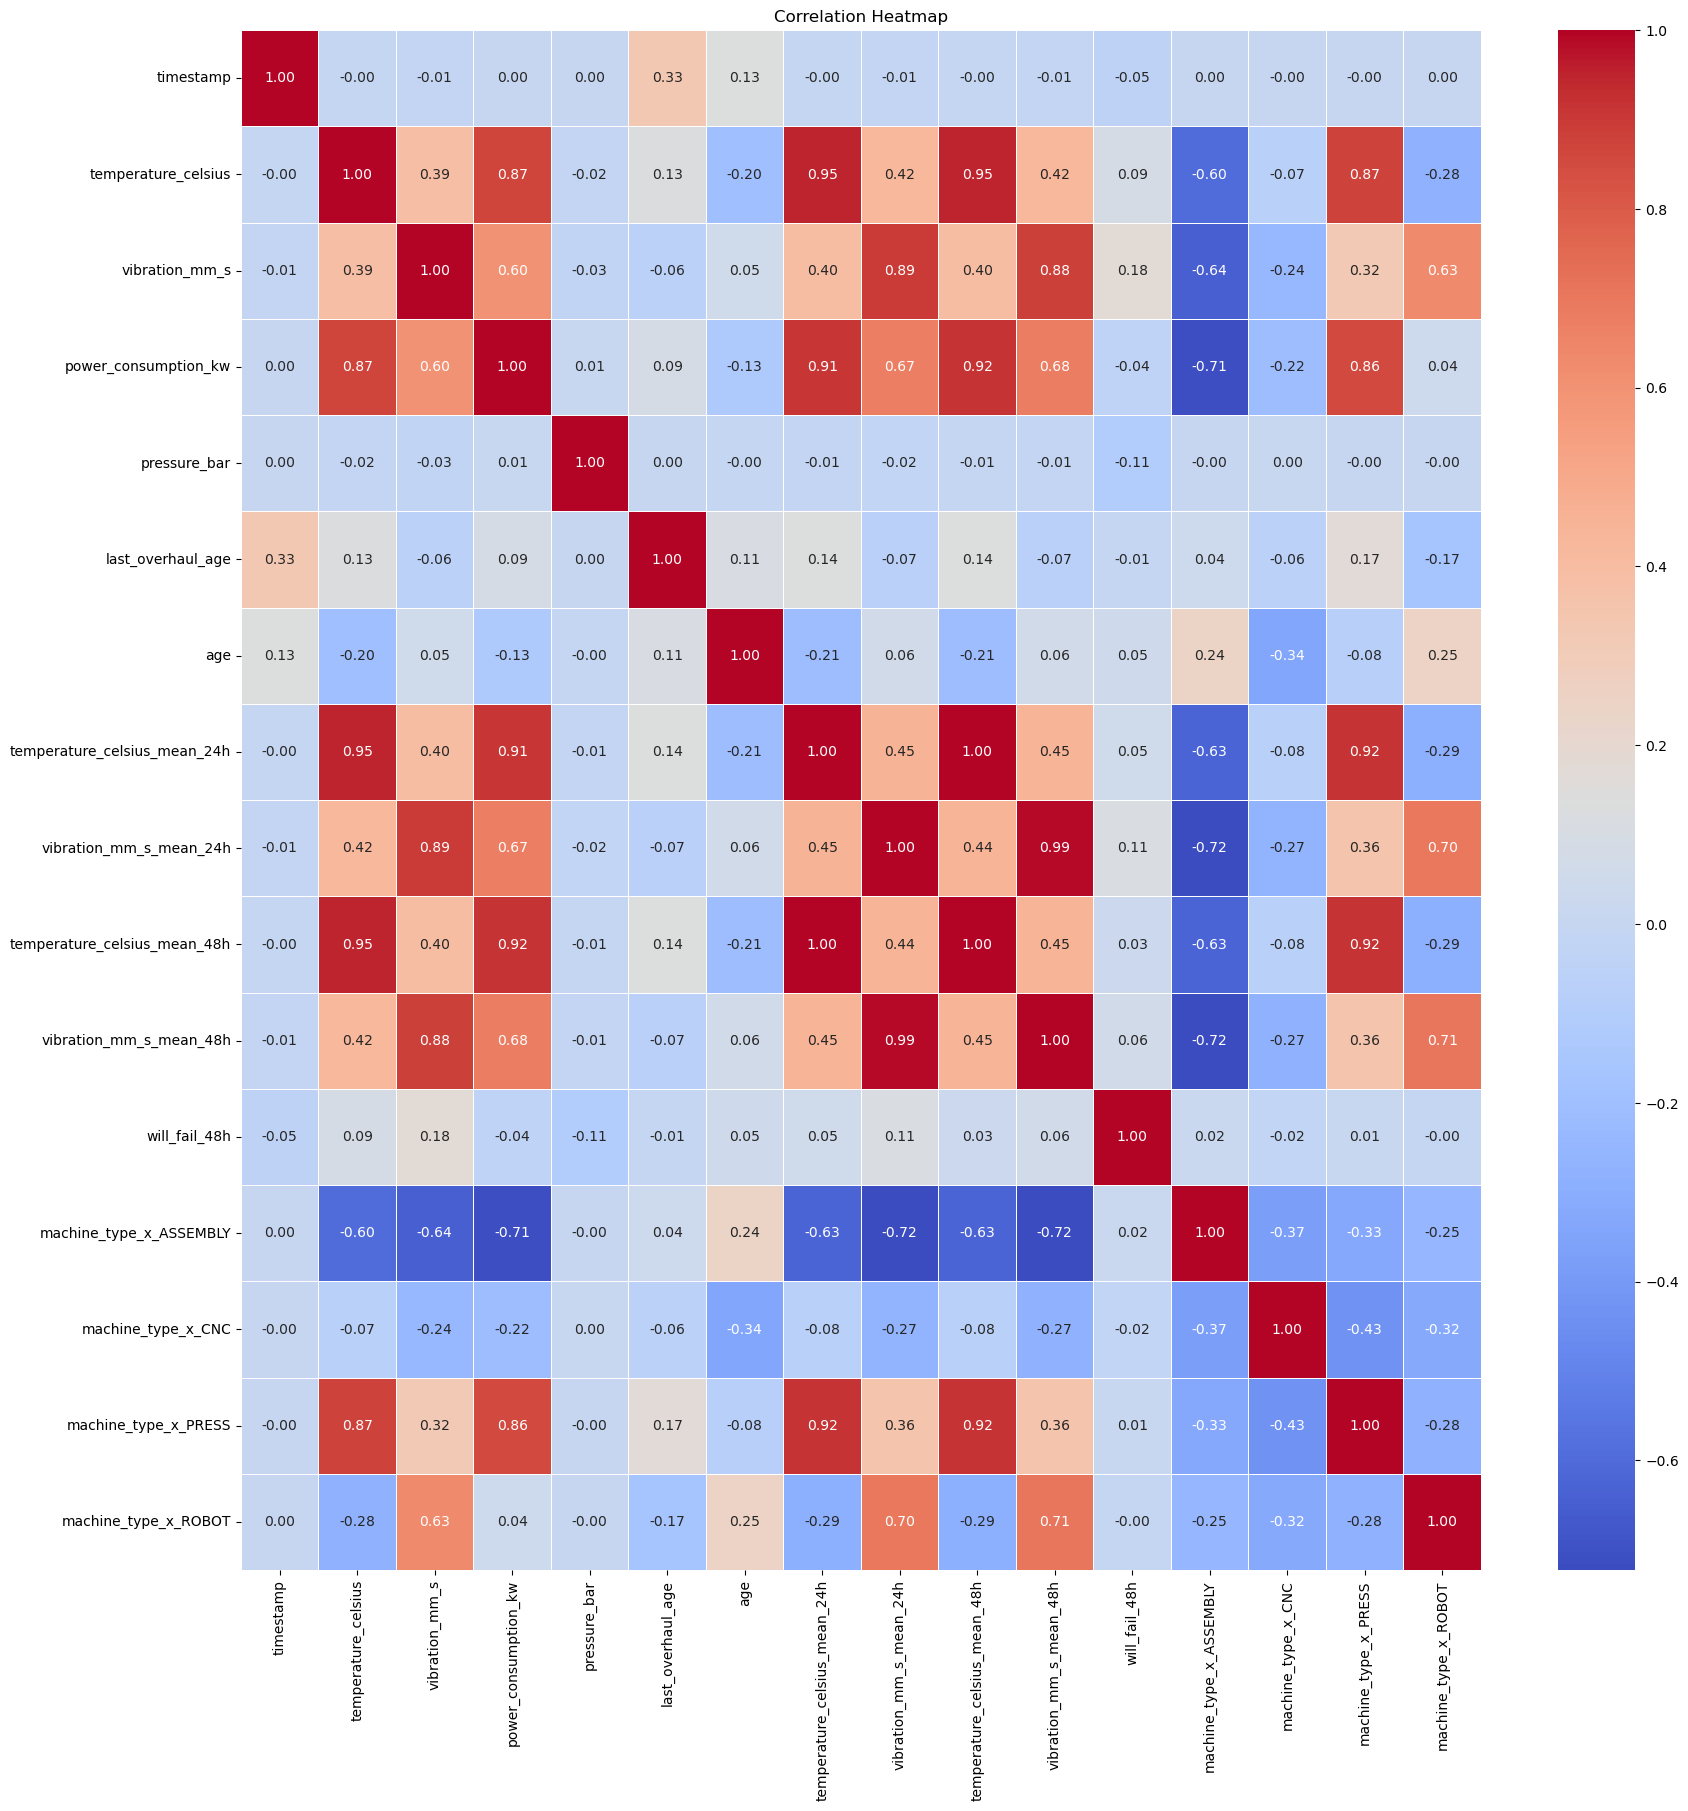

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

# One Hot Encode categorical features
categorical_columns = ['machine_type_x']
encoder = OneHotEncoder(sparse_output=False)
cat_encoded = encoder.fit_transform(df[categorical_columns])
df_cat_encoded = pd.DataFrame(cat_encoded, columns=encoder.get_feature_names_out(categorical_columns))
df_corr = pd.concat([df_transformed.drop(categorical_columns, axis=1), df_cat_encoded], axis=1)
df_corr = df_corr.drop(columns=['machine_id'])

# Heatmap
plt.figure(figsize=(20,20))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [45]:
corr = abs(df_corr.corr())
corr = corr[['will_fail_48h']].drop('will_fail_48h').sort_values(by=["will_fail_48h"],ascending=False)
print(corr)

                              will_fail_48h
vibration_mm_s                     0.175731
vibration_mm_s_mean_24h            0.113353
pressure_bar                       0.106221
temperature_celsius                0.089677
vibration_mm_s_mean_48h            0.061328
temperature_celsius_mean_24h       0.054324
timestamp                          0.046353
age                                0.045790
power_consumption_kw               0.042124
temperature_celsius_mean_48h       0.029444
machine_type_x_CNC                 0.022151
machine_type_x_ASSEMBLY            0.019494
last_overhaul_age                  0.008626
machine_type_x_PRESS               0.007507
machine_type_x_ROBOT               0.002941


In [79]:
feature_a_garder = list(corr.index[:10])
feature_a_garder.append('will_fail_48h')
df_final = df_transformed[feature_a_garder]


In [146]:
feature_a_garder

['vibration_mm_s',
 'vibration_mm_s_mean_24h',
 'pressure_bar',
 'temperature_celsius',
 'vibration_mm_s_mean_48h',
 'temperature_celsius_mean_24h',
 'timestamp',
 'age',
 'power_consumption_kw',
 'temperature_celsius_mean_48h',
 'will_fail_48h']

### Preprocessing / Gestion du désiquilibre des classes

In [94]:
from imblearn.under_sampling import RandomUnderSampler

def data_split_train_test(df,datesplit):
    df.sort_values(by=['timestamp'],ascending=False)
    df_train = df[df['timestamp']<datesplit]
    df_test = df[df['timestamp']>=datesplit]
    df_train = df_train.drop(columns=['timestamp'])
    df_test = df_test.drop(columns=['timestamp'])
    return df_train, df_test

def data_under_sample(df):
    # sous echantillonnage
    rus = RandomUnderSampler(random_state=42)
    X = df.drop(columns=['will_fail_48h'])
    y = df['will_fail_48h']
    X2, y2 = rus.fit_resample(X,y)

    # on concatène X et y (sinon je rencontre un soucis d'index)
    X2 = X2.reset_index(drop=True)
    y2 = y2.reset_index(drop=True)
    X2['will_fail_48h'] = y2
    # je retire la premiere lien car contient des NaN
    X2 = X2.drop(0)

    # on sépare X et y
    X = X2.drop(columns=['will_fail_48h'])
    y = X2['will_fail_48h']
    return X,y

In [95]:
# split train test
df_train, df_test = data_split_train_test(df_final,"2025-10-01")

# random under sampling 
X_train, y_train = data_under_sample(df_train)
X_test = df_test.drop(columns=['will_fail_48h'])
y_test = df_test['will_fail_48h']


In [96]:
print(f"Répartition après sous échantillonnage : classe 0={y_train.sum()} classe 1={len(y_train)-y_train.sum()}")

Répartition après sous échantillonnage : classe 0=7824 classe 1=7823


### Modelisation (Random Forest et XGBoost)

In [143]:
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

Best params = {'rf__max_depth': 11, 'rf__max_leaf_nodes': 9, 'rf__n_estimators': 300}
Best Score = 0.8615713254446449
Accuracy= 0.9848970251716247
Precision= 0.5841885470203569
Recall= 0.8679017734080676
F1 score= 0.6343423365091111
[[85828  1236]
 [   84   252]]


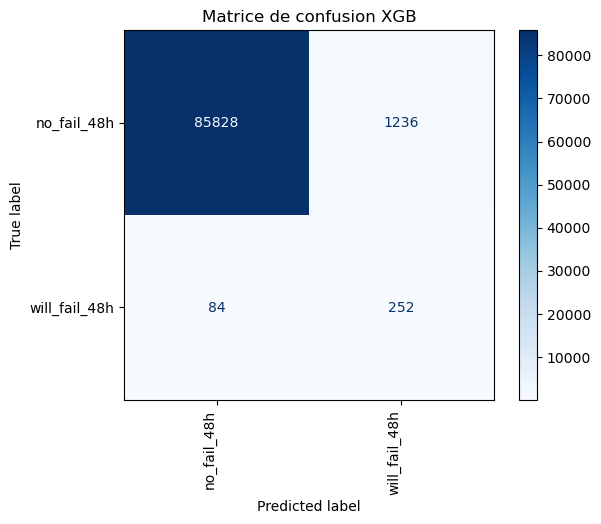

In [98]:
# RANDOM FOREST avec GRID SEARCH pour trouver les hypers paramètres optimaux

class_names = ['no_fail_48h', 'will_fail_48h']

params = {
    "rf__n_estimators": [100,200,300],
    "rf__max_depth": [3,5,8,11],
    "rf__max_leaf_nodes": [3,5,7,9]
}

preprocessing = ColumnTransformer(
    transformers=[
    ("scaler", StandardScaler(),['vibration_mm_s',
                                 'vibration_mm_s_mean_24h',
                                 'pressure_bar',
                                 'temperature_celsius',
                                 'vibration_mm_s_mean_48h',
                                 'temperature_celsius_mean_24h',
                                 'age',
                                 'power_consumption_kw',
                                 'temperature_celsius_mean_48h'])]
)

rf_pipeline = Pipeline([
    ('preprecessing', preprocessing),
    ('rf', RandomForestClassifier())
])

gscv_rf = GridSearchCV(rf_pipeline, params, n_jobs=2,cv=5)
gscv_rf.fit(X_train, y_train)

print("Best params =",gscv_rf.best_params_)
print("Best Score =",gscv_rf.best_score_)

y_pred_rf = gscv_rf.best_estimator_.predict(X_test)
print("Accuracy=",accuracy_score(y_test, y_pred_rf))
print("Precision=",precision_score(y_test, y_pred_rf,average='macro'))
print("Recall=",recall_score(y_test, y_pred_rf,average='macro'))
print("F1 score=",f1_score(y_test, y_pred_rf,average='macro'))

disp = ConfusionMatrixDisplay.from_estimator(
        gscv_rf,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=None,
    )
disp.ax_.set_title("Matrice de confusion XGB")
disp.ax_.set_xlabel("Predicted label")
disp.ax_.set_ylabel("True label")
disp.ax_.set_xticklabels(labels=class_names, rotation=90, ha='right')
print(disp.confusion_matrix)
plt.show()

Best params = {'xgb__max_depth': np.int64(3), 'xgb__n_estimators': 100, 'xgb__tree_method': 'auto'}
Best Score = 0.8809354926652351
Accuracy= 0.9566132723112128
Precision= 0.5352016287084302
Recall= 0.9041052996591451
F1 score= 0.5544117949803791
[[83322  3742]
 [   50   286]]


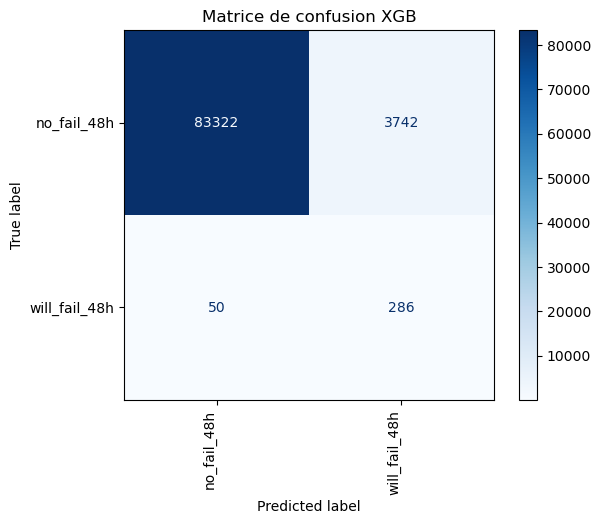

In [100]:
# XGBOOST avec GRID SEARCH pour trouver les hypers paramètres optimaux

class_names = ['no_fail_48h', 'will_fail_48h']

params = {
    "xgb__max_depth": np.arange(3,10),
    "xgb__n_estimators": [100,200],
    "xgb__tree_method" :  ["auto"] 
}

preprocessing = ColumnTransformer(
    transformers=[
    ("scaler", StandardScaler(),['vibration_mm_s',
                                 'vibration_mm_s_mean_24h',
                                 'pressure_bar',
                                 'temperature_celsius',
                                 'vibration_mm_s_mean_48h',
                                 'temperature_celsius_mean_24h',
                                 'age',
                                 'power_consumption_kw',
                                 'temperature_celsius_mean_48h'])
    ]
)

xgb_pipeline = Pipeline([
    ('preprecessing', preprocessing),
    ('xgb',XGBClassifier())
])

gscv_xgb = GridSearchCV(xgb_pipeline, params, n_jobs=2,cv=5)
gscv_xgb.fit(X_train, y_train)

print("Best params =",gscv_xgb.best_params_)
print("Best Score =",gscv_xgb.best_score_)

y_pred_xgb = gscv_xgb.best_estimator_.predict(X_test)
print("Accuracy=",accuracy_score(y_test, y_pred_xgb))
print("Precision=",precision_score(y_test, y_pred_xgb,average='macro'))
print("Recall=",recall_score(y_test, y_pred_xgb,average='macro'))
print("F1 score=",f1_score(y_test, y_pred_xgb,average='macro'))

disp = ConfusionMatrixDisplay.from_estimator(
        gscv_xgb,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=None,
    )
disp.ax_.set_title("Matrice de confusion XGB")
disp.ax_.set_xlabel("Predicted label")
disp.ax_.set_ylabel("True label")
disp.ax_.set_xticklabels(labels=class_names, rotation=90, ha='right')
print(disp.confusion_matrix)
plt.show()

### Sauvegarde du modèle XGBoost

In [141]:
import joblib
joblib.dump(gscv_xgb.best_estimator_, 'best_model.pkl', compress = True)


['best_model.pkl']